<a href="https://colab.research.google.com/github/Champei/MovieRecommender-Analysis-/blob/main/Movie_Recommender.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

path='/content/drive/MyDrive/googlecolab/ml-100k'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir(path))

['allbut.pl', 'ua.base', 'u5.test', 'u.item', 'u.occupation', 'u5.base', 'ub.test', 'u2.base', 'u1.base', 'README', 'u1.test', 'u2.test', 'u4.test', 'u3.base', 'u3.test', 'ua.test', 'ub.base', 'u4.base', 'u.info', 'u.data', 'u.genre', 'u.user', 'mku.sh']


In [ ]:


import pandas as pd

ratings = pd.read_csv(path+'/u.data', sep='\t', names=['user_id', 'movie_id', 'rating', 'timestamp'])


movies = pd.read_csv(path+'/u.item', sep='|', encoding='latin-1', header=None, usecols=[0, 1])
movies.columns = ['movie_id', 'title']


df = pd.merge(ratings, movies, on='movie_id')
print(df.head())

   user_id  movie_id  rating  timestamp                       title
0      196       242       3  881250949                Kolya (1996)
1      186       302       3  891717742    L.A. Confidential (1997)
2       22       377       1  878887116         Heavyweights (1994)
3      244        51       2  880606923  Legends of the Fall (1994)
4      166       346       1  886397596         Jackie Brown (1997)


In [ ]:
genre_cols = [
    "unknown", "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"
]
cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + genre_cols

movies = pd.read_csv(path+'/u.item', sep='|', names=cols, encoding='latin-1')

# Merge again with the ratings
df = pd.merge(ratings, movies, on='movie_id')
display(df.head())
print(df.isnull().sum())

,user_id,movie_id,rating,timestamp,title,release_date,video_release_date,imdb_url,unknown,Action,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,0,0,0,0,0


user_id                    0
movie_id                   0
rating                     0
timestamp                  0
title                      0
release_date               9
video_release_date    100000
imdb_url                  13
unknown                    0
Action                     0
Adventure                  0
Animation                  0
Children's                 0
Comedy                     0
Crime                      0
Documentary                0
Drama                      0
Fantasy                    0
Film-Noir                  0
Horror                     0
Musical                    0
Mystery                    0
Romance                    0
Sci-Fi                     0
Thriller                   0
War                        0
Western                    0
dtype: int64


In [ ]:
nullrows = df[df['release_date'].isnull()]
print(nullrows)

       user_id  movie_id  rating  timestamp    title release_date  \
2172       130       267       5  875801239  unknown          NaN   
3781         5       267       4  875635064  unknown          NaN   
7245       268       267       3  875742077  unknown          NaN   
12475      297       267       3  875409139  unknown          NaN   
14756      319       267       4  875707690  unknown          NaN   
15292        1       267       4  875692955  unknown          NaN   
49295      532       267       3  875441348  unknown          NaN   
93523      833       267       1  875655669  unknown          NaN   
99723      422       267       4  875655986  unknown          NaN   

       video_release_date imdb_url  unknown  Action  ...  Fantasy  Film-Noir  \
2172                  NaN      NaN        1       0  ...        0          0   
3781                  NaN      NaN        1       0  ...        0          0   
7245                  NaN      NaN        1       0  ...        0    

In [ ]:

df = df[df['title'] != 'unknown']

print(df['release_date'].isnull().sum())

df = df[df['title'] != 'Good Morning (1971)']
df=df.drop('video_release_date', axis=1)
df=df.drop('unknown', axis=1)
df

0


,user_id,movie_id,rating,timestamp,title,release_date,imdb_url,Action,Adventure,Animation,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,0,...,0,0,0,0,0,1,0,0,1,1
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,880,476,3,880175444,"First Wives Club, The (1996)",14-Sep-1996,http://us.imdb.com/M/title-exact?First%20Wives...,0,0,0,...,0,0,0,0,0,0,0,0,0,0
99996,716,204,5,879795543,Back to the Future (1985),01-Jan-1985,http://us.imdb.com/M/title-exact?Back%20to%20t...,0,0,0,...,0,0,0,0,0,0,1,0,0,0
99997,276,1090,1,874795795,Sliver (1993),01-Jan-1993,http://us.imdb.com/M/title-exact?Sliver%20(1993),0,0,0,...,0,0,0,0,0,0,0,1,0,0
99998,13,225,2,882399156,101 Dalmatians (1996),27-Nov-1996,http://us.imdb.com/M/title-exact?101%20Dalmati...,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99990 entries, 0 to 99999
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       99990 non-null  int64 
 1   movie_id      99990 non-null  int64 
 2   rating        99990 non-null  int64 
 3   timestamp     99990 non-null  int64 
 4   title         99990 non-null  object
 5   release_date  99990 non-null  object
 6   imdb_url      99986 non-null  object
 7   Action        99990 non-null  int64 
 8   Adventure     99990 non-null  int64 
 9   Animation     99990 non-null  int64 
 10  Children's    99990 non-null  int64 
 11  Comedy        99990 non-null  int64 
 12  Crime         99990 non-null  int64 
 13  Documentary   99990 non-null  int64 
 14  Drama         99990 non-null  int64 
 15  Fantasy       99990 non-null  int64 
 16  Film-Noir     99990 non-null  int64 
 17  Horror        99990 non-null  int64 
 18  Musical       99990 non-null  int64 
 19  Mystery  

In [ ]:
df.describe()

,user_id,movie_id,rating,timestamp,Action,Adventure,Animation,Children's,Comedy,Crime,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
count,99990.000000,99990.000000,99990.000000,9.999000e+04,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,...,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000,99990.000000
mean,462.501120,425.534923,3.529893,8.835296e+08,0.255916,0.137544,0.036054,0.071827,0.298350,0.080558,...,0.013521,0.017332,0.053175,0.049545,0.052455,0.194629,0.127313,0.218742,0.093989,0.018542
std,266.611967,330.797909,1.125656,5.343579e+06,0.436377,0.344422,0.186424,0.258203,0.457536,0.272157,...,0.115493,0.130505,0.224384,0.217004,0.222944,0.395917,0.333325,0.413395,0.291815,0.134901
min,1.000000,1.000000,1.000000,8.747247e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,254.000000,175.000000,3.000000,8.794488e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,447.000000,322.000000,4.000000,8.828270e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,682.000000,631.000000,4.000000,8.882600e+08,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,943.000000,1682.000000,5.000000,8.932866e+08,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Rating Distribution**

Most ratings are between 3-5, Users tend to give higher ratings, Data is positively skewed

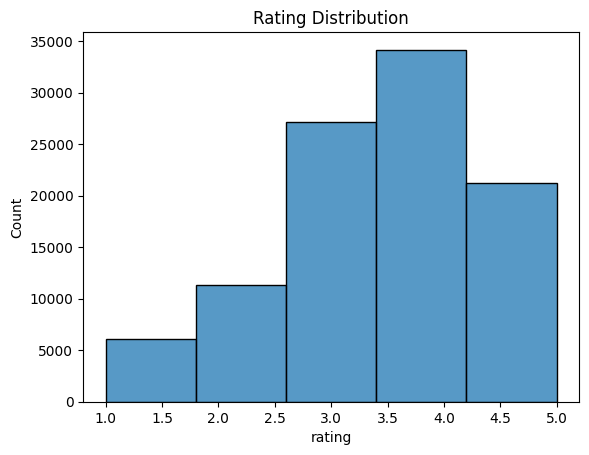

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['rating'],bins=5)
plt.title("Rating Distribution")
plt.show()

**Popular Movies**

Most rated movies , most popular movies, movies user interact with most

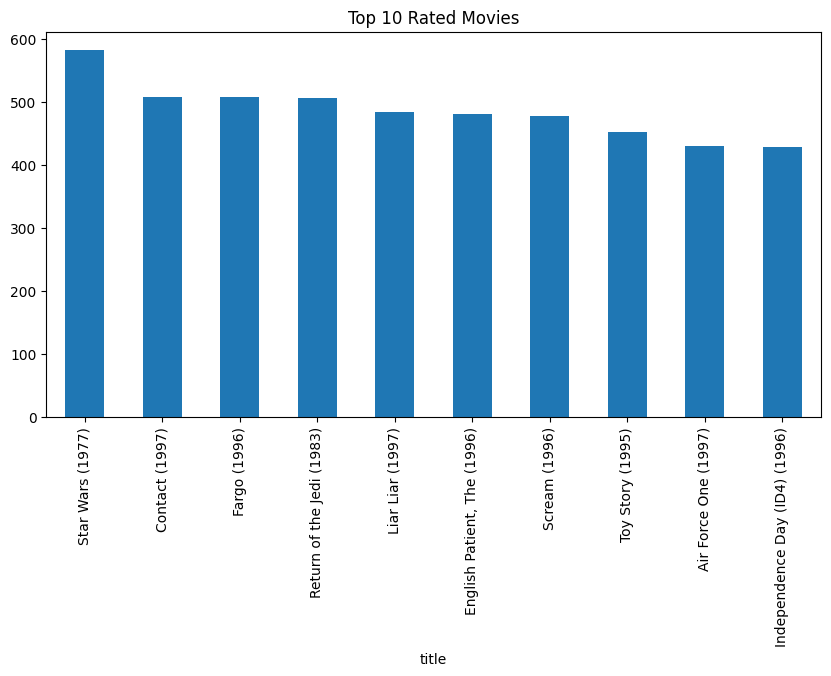

In [ ]:
top_movies=df['title'].value_counts().head(10)
top_movies=df['title'].value_counts().head(10)
top_movies.plot(kind='bar',figsize=(10,5))

plt.title("Top 10 Rated Movies")
plt.show()

**Top Rated Movies**

highest rated movies

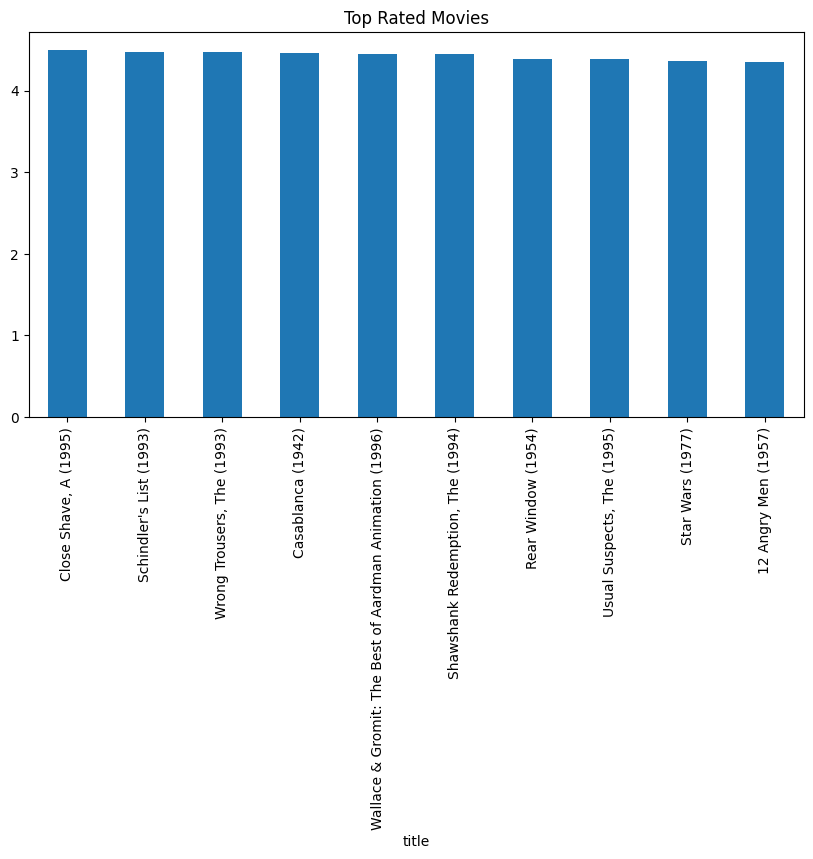

In [ ]:
popular_movies=df.groupby('title').filter(lambda x: len(x) > 50)
avg_rating = popular_movies.groupby('title')['rating'].mean().sort_values(ascending=False).head(10)
  # Groups data by movie title and calculated average rating for each moviea

avg_rating.plot(kind='bar',figsize=(10,5))
plt.title("Top Rated Movies")
plt.show()

GENRE POPULARITY

--- Most popular Genres = Drama, Comedy, Action, Thriller, Romance, , Sci-fi



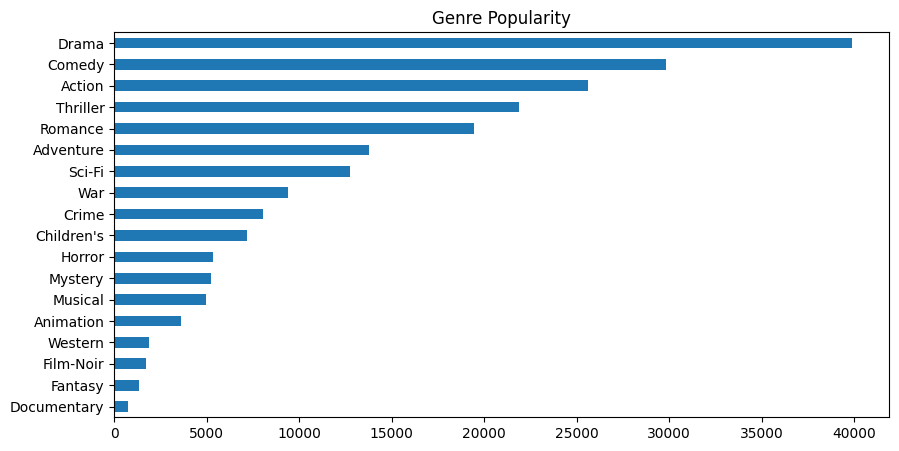

In [ ]:
genre_cols = [
   "Action", "Adventure", "Animation", "Children's", "Comedy",
    "Crime", "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror",
    "Musical", "Mystery", "Romance", "Sci-Fi", "Thriller", "War", "Western"] # adjust

df[genre_cols].sum().sort_values().plot(kind='barh',figsize=(10,5))
plt.title("Genre Popularity")
plt.show()

**AVERAGE RATING PER GENRE-Genre Quality**

Film-Noir has highest average rating.

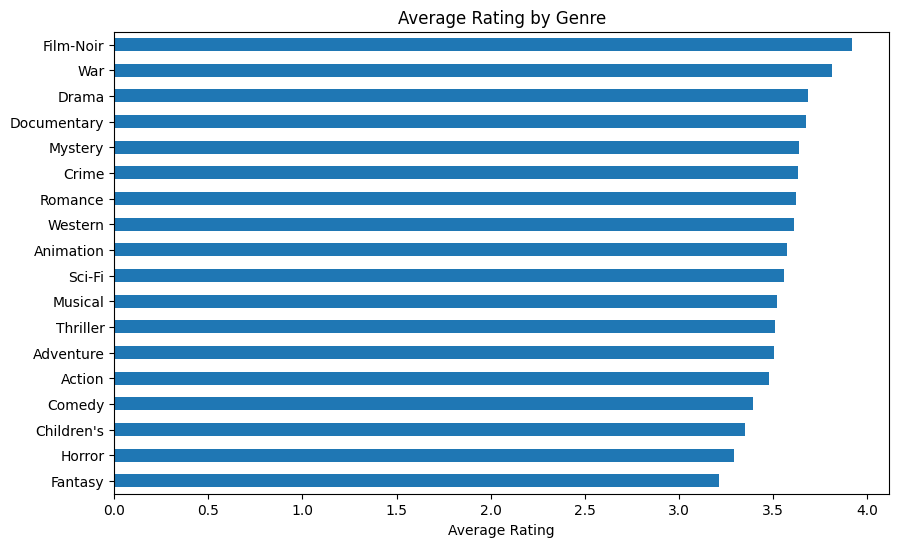

In [ ]:
genre_avg = {}

for genre in genre_cols:
    genre_avg[genre] = df[df[genre] == 1]['rating'].mean()

import pandas as pd
genre_avg = pd.Series(genre_avg).sort_values()

genre_avg.plot(kind='barh', figsize=(10,6))
plt.title("Average Rating by Genre")
plt.xlabel("Average Rating")
plt.show()

**Average Rating vs Number of Ratings**

Popular movies tend to have stable ratings less rated movies=noisy ratings

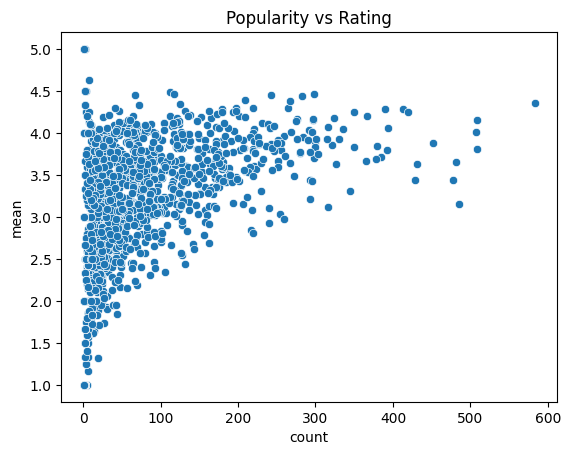

In [ ]:
ratings = df.groupby('title')['rating'].agg(['mean','count'])

sns.scatterplot(x='count', y='mean', data=ratings)
plt.title("Popularity vs Rating")
plt.show()

**Sparsity**


Dataset is highly sparse, Typical in recommendation systems

In [ ]:
matrix = df.pivot_table(index='user_id', columns='title', values='rating')
print(matrix.isnull().sum().sum() / (matrix.shape[0]*matrix.shape[1]))

#Sparsity :0.93   (93% missing values in matrix) , harder to find similarity
matrix

0.9363968847662107


title,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Wyatt Earp (1994),Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),Á köldum klaka (Cold Fever) (1994)
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
